In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from glob import glob
from tqdm import tqdm
import xarray as xr
import os, sys
import scipy
import pandas as pd
from scipy.ndimage import gaussian_filter
from sklearn.decomposition import PCA
from scipy import stats

from scipy import interpolate

from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

# from cinplaAnalysis.utils import *
import quantities as pq

%matplotlib inline

In [2]:
from icsd import StandardCSD, DeltaiCSD, StepiCSD

/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/icsd.py:1158: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
  if f_type is not 'identity' and f_order is None:


In [3]:
import matplotlib

font = {'size'   : 12}

matplotlib.rc('font', **font)

In [4]:
matplotlib.rcParams['savefig.pad_inches'] = 0

In [5]:
def plotFig(ax,csd,breaks=None,absmax=None,timeLimited=False,plotCB=True,xlabels=False,title=None,xlim=None,ylim=None):

    if breaks is not None:
        for b in breaks:
            ax.plot([0,3000],[b,b],c='k')

    if absmax is None:
        absmax = np.max(np.abs(csd))

    rms = np.mean(np.sqrt(csd**2))
    
    #im = ax.imshow(np.array(csd)/rms, origin='lower',cmap='bwr_r',vmin=-0.1,vmax=.1)#, vmin =-absmax,vmax=absmax, cmap='bwr_r')
    im = ax.imshow(np.array(csd), origin='lower', vmin =-absmax,vmax=absmax, cmap='bwr_r')
    ax.axis(ax.axis('tight'))

    if plotCB:
        cb = plt.colorbar(im, ax=ax)
        cb.formatter.set_powerlimits((0,0))

                # Get the scientific notation text (e.g. 1e3)
        offset = cb.ax.yaxis.get_offset_text()
        
        # Move it: x > 1 pushes right of colorbar, y > 1 pushes above
        offset.set_x(5)
        offset.set_y(50)


    ax.set_yticklabels([])

    if xlabels:
        ax.set_xticks([0,50],labels=['0','50'])
        # ax.set_xlabel('Time (ms)')
    else:
        ax.set_xticklabels([])

    if timeLimited:
        ax.set_xlim([50,100])
    else:
        ax.set_xlim([0,50])

    if title:
        plt.title(title)

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    plt.tight_layout()

In [6]:
def produce_iCSD(data,lfpIdx,diam):
    
    totalLFPHighRes = data[:,lfpIdx] # LFP, 20 um spacing
    totalLFPLowRes = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:2] # LFP, 40 um spacing
    totalLFPLowResHalf = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:4] # LFP, 80 um spacing
    totalLFPLowResQuarter = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:8] # LFP, 160 um spacing

    sigma = .277 * pq.S / pq.m                         # [S/m] or [1/(ohm*m)]
    sigma_top = .277 * pq.S / pq.m                     # [S/m] or [1/(ohm*m)]
    
    # Input dictionaries for each method
    
    step_input_high = {
        'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
        'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
        'sigma' : sigma,
        'sigma_top':sigma_top,
        'h':20E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam,
        'tol':1e-12
    }
    
    step_input_low = {
        'lfp' : totalLFPLowRes.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 40 * np.arange(0,51) * 1e-6 * pq.m,
        'sigma' : sigma,
        'sigma_top':sigma_top,
        'h':40E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    step_input_low_half = {
        'lfp' : totalLFPLowResHalf.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 80 * np.arange(0,totalLFPLowResHalf.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'sigma_top':sigma_top,
        'h':80E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    step_input_low_quarter = {
        'lfp' : totalLFPLowResQuarter.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 160 * np.arange(0,totalLFPLowResQuarter.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'sigma_top':sigma_top,
        'h':160E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    std_input_high = {
        'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
        'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low = {
        'lfp' : totalLFPLowRes.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 40 * np.arange(0,51) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low_half = {
        'lfp' : totalLFPLowResHalf.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 80 * np.arange(0,totalLFPLowResHalf.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low_quarter = {
        'lfp' : totalLFPLowResQuarter.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 160 * np.arange(0,totalLFPLowResQuarter.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    
    icsd_high = StepiCSD(**step_input_high)
    icsd_low = StepiCSD(**step_input_low)
    icsd_low_half = StepiCSD(**step_input_low_half)
    icsd_low_quarter = StepiCSD(**step_input_low_quarter)
    
    icsd_high_std = StandardCSD(**std_input_high)
    icsd_low_std = StandardCSD(**std_input_low)
    icsd_low_half_std = StandardCSD(**std_input_low_half)
    icsd_low_quarter_std = StandardCSD(**std_input_low_quarter)

    return icsd_high

    

In [7]:
def produce_iCSD_all(data,lfpIdx,diam):
    
    totalLFPHighRes = data[:,lfpIdx] # LFP, 20 um spacing
    totalLFPLowRes = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:2] # LFP, 40 um spacing
    totalLFPLowResHalf = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:4] # LFP, 80 um spacing
    totalLFPLowResQuarter = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:8] # LFP, 160 um spacing

    sigma = 0.277 * pq.S / pq.m                         # [S/m] or [1/(ohm*m)]
    sigma_top = 0.277 * pq.S / pq.m                     # [S/m] or [1/(ohm*m)]
    
    # Input dictionaries for each method
    
    step_input_high = {
        'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
        'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
        'sigma' : sigma,
        'sigma_top':sigma_top,
        'h':20E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam,
        'tol':1e-12
    }
    
    step_input_low = {
        'lfp' : totalLFPLowRes.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 40 * np.arange(0,51) * 1e-6 * pq.m,
        'sigma' : sigma,
        'sigma_top':sigma_top,
        'h':40E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam,
        'tol':1e-12
    }
    
    step_input_low_half = {
        'lfp' : totalLFPLowResHalf.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 80 * np.arange(0,totalLFPLowResHalf.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'sigma_top':sigma_top,
        'h':80E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam,
        'tol':1e-12
    }
    
    step_input_low_quarter = {
        'lfp' : totalLFPLowResQuarter.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 160 * np.arange(0,totalLFPLowResQuarter.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'sigma_top':sigma_top,
        'h':160E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam,
        'tol':1e-12
    }
    
    std_input_high = {
        'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
        'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low = {
        'lfp' : totalLFPLowRes.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 40 * np.arange(0,51) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low_half = {
        'lfp' : totalLFPLowResHalf.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 80 * np.arange(0,totalLFPLowResHalf.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low_quarter = {
        'lfp' : totalLFPLowResQuarter.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 160 * np.arange(0,totalLFPLowResQuarter.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    
    icsd_high = StepiCSD(**step_input_high)
    icsd_low = StepiCSD(**step_input_low)
    icsd_low_half = StepiCSD(**step_input_low_half)
    icsd_low_quarter = StepiCSD(**step_input_low_quarter)
    
    icsd_high_std = StandardCSD(**std_input_high)
    icsd_low_std = StandardCSD(**std_input_low)
    icsd_low_half_std = StandardCSD(**std_input_low_half)
    icsd_low_quarter_std = StandardCSD(**std_input_low_quarter)

    return icsd_high, icsd_low, icsd_low_half, icsd_low_quarter

In [8]:
def produce_sCSD(data,lfpIdx,diam):
    
    totalLFPHighRes = data[:,lfpIdx] # LFP, 20 um spacing
    totalLFPLowRes = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:2] # LFP, 40 um spacing
    totalLFPLowResHalf = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:4] # LFP, 80 um spacing
    totalLFPLowResQuarter = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:8] # LFP, 160 um spacing

    sigma = 0.277 * pq.S / pq.m                         # [S/m] or [1/(ohm*m)]
    sigma_top = 0.277 * pq.S / pq.m                     # [S/m] or [1/(ohm*m)]
    
    # Input dictionaries for each method
    
    step_input_high = {
        'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
        'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
        'sigma' : sigma,
        'sigma_top':sigma_top,
        'h':20E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    step_input_low = {
        'lfp' : totalLFPLowRes.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 40 * np.arange(0,51) * 1e-6 * pq.m,
        'sigma' : sigma,
        'sigma_top':sigma_top,
        'h':40E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    step_input_low_half = {
        'lfp' : totalLFPLowResHalf.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 80 * np.arange(0,totalLFPLowResHalf.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'sigma_top':sigma_top,
        'h':80E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    step_input_low_quarter = {
        'lfp' : totalLFPLowResQuarter.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 160 * np.arange(0,totalLFPLowResQuarter.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'sigma_top':sigma_top,
        'h':160E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    std_input_high = {
        'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
        'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low = {
        'lfp' : totalLFPLowRes.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 40 * np.arange(0,51) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low_half = {
        'lfp' : totalLFPLowResHalf.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 80 * np.arange(0,totalLFPLowResHalf.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low_quarter = {
        'lfp' : totalLFPLowResQuarter.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 160 * np.arange(0,totalLFPLowResQuarter.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    
    icsd_high = StepiCSD(**step_input_high)
    icsd_low = StepiCSD(**step_input_low)
    icsd_low_half = StepiCSD(**step_input_low_half)
    icsd_low_quarter = StepiCSD(**step_input_low_quarter)
    
    icsd_high_std = StandardCSD(**std_input_high)
    icsd_low_std = StandardCSD(**std_input_low)
    icsd_low_half_std = StandardCSD(**std_input_low_half)
    icsd_low_quarter_std = StandardCSD(**std_input_low_quarter)

    return icsd_high_std

In [9]:
def produce_sCSD_all(data,lfpIdx,diam):
    
    totalLFPHighRes = data[:,lfpIdx] # LFP, 20 um spacing
    totalLFPLowRes = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:2] # LFP, 40 um spacing
    totalLFPLowResHalf = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:4] # LFP, 80 um spacing
    totalLFPLowResQuarter = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:8] # LFP, 160 um spacing

    sigma = 0.277 * pq.S / pq.m                         # [S/m] or [1/(ohm*m)]
    sigma_top = 0.277 * pq.S / pq.m                     # [S/m] or [1/(ohm*m)]
    
    # Input dictionaries for each method
    
    step_input_high = {
        'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
        'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
        'sigma' : sigma,
        'sigma_top':sigma_top,
        'h':20E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    step_input_low = {
        'lfp' : totalLFPLowRes.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 40 * np.arange(0,51) * 1e-6 * pq.m,
        'sigma' : sigma,
        'sigma_top':sigma_top,
        'h':40E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    step_input_low_half = {
        'lfp' : totalLFPLowResHalf.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 80 * np.arange(0,totalLFPLowResHalf.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'sigma_top':sigma_top,
        'h':80E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    step_input_low_quarter = {
        'lfp' : totalLFPLowResQuarter.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 160 * np.arange(0,totalLFPLowResQuarter.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'sigma_top':sigma_top,
        'h':160E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    std_input_high = {
        'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
        'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low = {
        'lfp' : totalLFPLowRes.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 40 * np.arange(0,51) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low_half = {
        'lfp' : totalLFPLowResHalf.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 80 * np.arange(0,totalLFPLowResHalf.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low_quarter = {
        'lfp' : totalLFPLowResQuarter.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 160 * np.arange(0,totalLFPLowResQuarter.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }

    
    icsd_high_std = StandardCSD(**std_input_high)
    icsd_low_std = StandardCSD(**std_input_low)
    icsd_low_half_std = StandardCSD(**std_input_low_half)
    icsd_low_quarter_std = StandardCSD(**std_input_low_quarter)

    return icsd_high_std, icsd_low_std, icsd_low_half_std, icsd_low_quarter_std

In [10]:
def produce_oCSD(data,lfp_idx,disk_fullDensity_idx):

    ### Calculates oCSD for 40, 80, and 160 um electrode spacing, with rho of 500 um, by taking the sum of neighboring electrodes in the 20 um case

    totalLFPHighRes = data[:,lfpIdx] # LFP, 20 um spacing
    totalLFPLowRes = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:2] # LFP, 40 um spacing
    totalLFPLowResHalf = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:4] # LFP, 80 um spacing
    totalLFPLowResQuarter = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:8] # LFP, 160 um spacing

    objective_disk_full_highRes = data[:,disk_fullDensity_idx] # oCSD, 20 um spacing

    return objective_disk_full_highRes

In [12]:
def produce_oCSD_all(data,lfp_idx,disk_fullDensity_idx):

    ### Calculates oCSD for 40, 80, and 160 um electrode spacing, with rho of 500 um, by taking the sum of neighboring electrodes in the 20 um case

    totalLFPHighRes = data[:,lfpIdx] # LFP, 20 um spacing
    totalLFPLowRes = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:2] # LFP, 40 um spacing
    totalLFPLowResHalf = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:4] # LFP, 80 um spacing
    totalLFPLowResQuarter = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:8] # LFP, 160 um spacing

    objective_disk_full_highRes = data[:,disk_fullDensity_idx] # oCSD, 20 um spacing

    objective_disk_full_lowRes = np.zeros_like(totalLFPLowRes)
    objective_disk_half_lowRes = np.zeros_like(totalLFPLowResHalf)
    objective_disk_quarter_lowRes = np.zeros_like(totalLFPLowResQuarter)
    
    for l in range(objective_disk_full_lowRes.shape[1]):
        if l == 0:
            objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l+1]
        elif l == objective_disk_full_lowRes.shape[1]-1:
            objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l-1]
        else:
            objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l-1]+.5*objective_disk_full_highRes[:,2*l+1]
    
    for l in range(objective_disk_half_lowRes.shape[1]):
        if l == 0:
            objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l+1]
        elif l == objective_disk_half_lowRes.shape[1]-1:
            objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l-1]
        else:
            objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l-1]+.5*objective_disk_full_lowRes[:,2*l+1]
    
    for l in range(objective_disk_quarter_lowRes.shape[1]):
        if l == 0:
            objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l+1]
        elif l == objective_disk_quarter_lowRes.shape[1]-1:
            objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l-1]
        else:
            objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l-1]+.5*objective_disk_half_lowRes[:,2*l+1]

    return objective_disk_full_highRes, objective_disk_full_lowRes, objective_disk_half_lowRes, objective_disk_quarter_lowRes

In [13]:
def produce_nnCSD_all(data):

    ### Calculates oCSD for 40, 80, and 160 um electrode spacing, with rho of 500 um, by taking the sum of neighboring electrodes in the 20 um case

    objective_disk_full_highRes = data # oCSD, 20 um spacing

    objective_disk_full_lowRes = objective_disk_full_highRes[:,1:objective_disk_full_highRes.shape[1]-1:2].copy()
    objective_disk_half_lowRes = objective_disk_full_lowRes[:,1:objective_disk_full_lowRes.shape[1]-1:2].copy()
    objective_disk_quarter_lowRes = objective_disk_half_lowRes[:,1:objective_disk_half_lowRes.shape[1]-1:2].copy()
    
    for l in range(objective_disk_full_lowRes.shape[1]):
        if l == 0:
            objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l+1]
        elif l == objective_disk_full_lowRes.shape[1]-1:
            objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l-1]
        else:
            objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l-1]+.5*objective_disk_full_highRes[:,2*l+1]
    
    for l in range(objective_disk_half_lowRes.shape[1]):
        if l == 0:
            objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l+1]
        elif l == objective_disk_half_lowRes.shape[1]-1:
            objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l-1]
        else:
            objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l-1]+.5*objective_disk_full_lowRes[:,2*l+1]
    
    for l in range(objective_disk_quarter_lowRes.shape[1]):
        if l == 0:
            objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l+1]
        elif l == objective_disk_quarter_lowRes.shape[1]-1:
            objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l-1]
        else:
            objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l-1]+.5*objective_disk_half_lowRes[:,2*l+1]

    return objective_disk_full_highRes, objective_disk_full_lowRes, objective_disk_half_lowRes, objective_disk_quarter_lowRes

In [14]:
highResRerun = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/total.npy')/10
highResOriginal = np.load('/mnt/c/Users/tharayil/Downloads/csd_paper/highRes/total.npy')[1500:1550]/10

In [15]:
original_csd = np.load('/mnt/c/Users/tharayil/Downloads/csd_paper/radii/total.npy')[50:-1]/10

In [16]:
lfpIdx = np.arange(101)
csd500Idx = np.arange(101,202)
csd200Idx = np.arange(202,303)
csd50Idx = np.arange(303,404)
csd100Idx = np.arange(404,505)
csd20Idx = np.arange(505,606)

In [17]:
icsd_high_new_500, icsd_low_new_500, icsd_half_new_500, icsd_quarter_new_500 = produce_iCSD_all(highResRerun,lfpIdx,1000e-6*pq.m)
icsd_high_new_200, icsd_low_new_200, icsd_half_new_200, icsd_quarter_new_200 = produce_iCSD_all(highResRerun,lfpIdx,400e-6*pq.m)
icsd_high_new_100, icsd_low_new_100, icsd_half_new_100, icsd_quarter_new_100 = produce_iCSD_all(highResRerun,lfpIdx,200e-6*pq.m)
icsd_high_new_50, icsd_low_new_50, icsd_half_new_50, icsd_quarter_new_50 = produce_iCSD_all(highResRerun,lfpIdx,100e-6*pq.m)
icsd_high_new_20, icsd_low_new_20, icsd_half_new_20, icsd_quarter_new_20 = produce_iCSD_all(highResRerun,lfpIdx,40e-6*pq.m)

In [18]:
sCsd_high_new, sCsd_low_new, sCsd_half_new, sCsd_quarter_new = produce_sCSD_all(highResRerun,lfpIdx,40E-6 * pq.m)

In [19]:
ocsd_500, ocsd_low_500, ocsd_half_500, ocsd_quarter_500 = produce_oCSD_all(highResRerun,lfpIdx,csd500Idx)
ocsd_20, ocsd_low_20, ocsd_half_20, ocsd_quarter_20 = produce_oCSD_all(highResRerun,lfpIdx,csd20Idx)
ocsd_200, ocsd_low_200, ocsd_half_200, ocsd_quarter_200 = produce_oCSD_all(highResRerun,lfpIdx,csd200Idx)
ocsd_100, ocsd_low_100, ocsd_half_100, ocsd_quarter_100 = produce_oCSD_all(highResRerun,lfpIdx,csd100Idx)
ocsd_50, ocsd_low_50, ocsd_half_50, ocsd_quarter_50 = produce_oCSD_all(highResRerun,lfpIdx,csd50Idx)


In [20]:
icsd_20_original = produce_iCSD(highResOriginal,lfpIdx,40e-6*pq.m)

In [21]:
icsd_100_original = produce_iCSD(highResOriginal,lfpIdx,200e-6*pq.m)

In [22]:
ocsd_20_original= produce_oCSD(original_csd,lfpIdx,np.arange(303,404))

In [23]:
ocsd_100_original= produce_oCSD(original_csd,lfpIdx,np.arange(101,202))

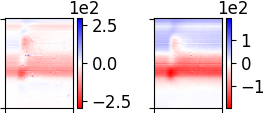

In [24]:
fig, axes = plt.subplots(1,2,figsize=(3,1.5))
plotFig(axes[0],icsd_high_new_20.get_csd())
plotFig(axes[1],icsd_20_original.get_csd())
plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/v3Figures/originalVsNew20.png',dpi=600)

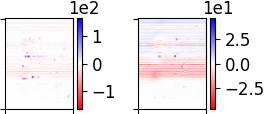

In [25]:
fig, axes = plt.subplots(1,2,figsize=(3,1.5))
plotFig(axes[0],icsd_high_new_100.get_csd())
plotFig(axes[1],icsd_100_original.get_csd())
plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/v3Figures/originalVsNew100.png',dpi=600)

In [24]:
nncsd = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_nncsd/total.npy')/10 # Loads LFP and oCSD averaged over trials, 20 um spacing, rho=500um


In [25]:
nncsd, nncsd_low, nncsd_half, nncsd_quarter = produce_nnCSD_all(nncsd)

In [ ]:
fig, ax = plt.subplots(2,4,figsize=(8,4))
plotFig(ax[0][0],ocsd_200.T)
plotFig(ax[0][1],ocsd_100.T)
plotFig(ax[0][2],ocsd_50.T)
plotFig(ax[0][3],ocsd_20.T)

plotFig(ax[1][0],nncsd.T)
plotFig(ax[1][1],nncsd.T)
plotFig(ax[1][2],nncsd.T)
plotFig(ax[1][3],nncsd.T)

fig, ax = plt.subplots(2,4,figsize=(8,4))
plotFig(ax[0][0],ocsd_low_200.T)
plotFig(ax[0][1],ocsd_low_100.T)
plotFig(ax[0][2],ocsd_low_50.T)
plotFig(ax[0][3],ocsd_low_20.T)

plotFig(ax[1][0],nncsd_low.T)
plotFig(ax[1][1],nncsd_low.T)
plotFig(ax[1][2],nncsd_low.T)
plotFig(ax[1][3],nncsd_low.T)

fig, ax = plt.subplots(2,4,figsize=(8,4))
plotFig(ax[0][0],ocsd_half_200.T)
plotFig(ax[0][1],ocsd_half_100.T)
plotFig(ax[0][2],ocsd_half_50.T)
plotFig(ax[0][3],ocsd_half_20.T)

plotFig(ax[1][0],nncsd_half.T)
plotFig(ax[1][1],nncsd_half.T)
plotFig(ax[1][2],nncsd_half.T)
plotFig(ax[1][3],nncsd_half.T)

fig, ax = plt.subplots(2,4,figsize=(8,4))
plotFig(ax[0][0],ocsd_quarter_200.T)
plotFig(ax[0][1],ocsd_quarter_100.T)
plotFig(ax[0][2],ocsd_quarter_50.T)
plotFig(ax[0][3],ocsd_quarter_20.T)

plotFig(ax[1][0],nncsd_quarter.T)
plotFig(ax[1][1],nncsd_quarter.T)
plotFig(ax[1][2],nncsd_quarter.T)
plotFig(ax[1][3],nncsd_quarter.T)

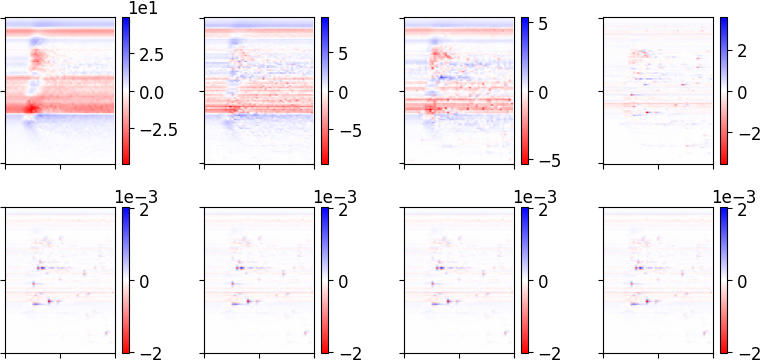

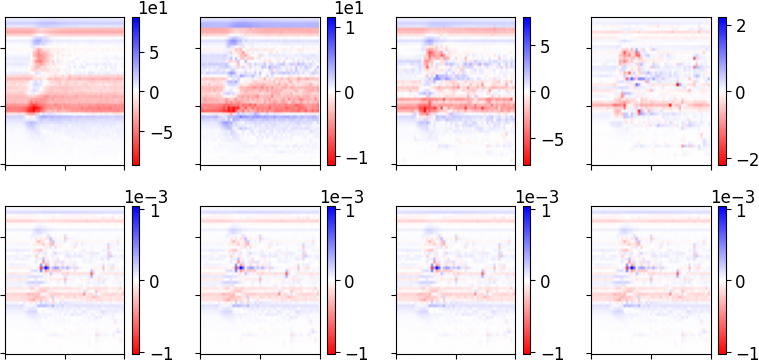

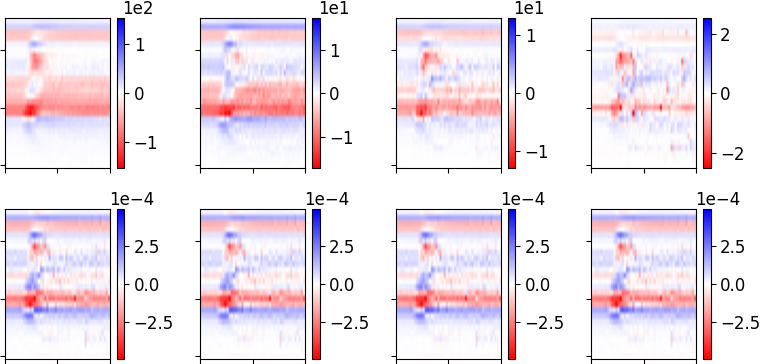

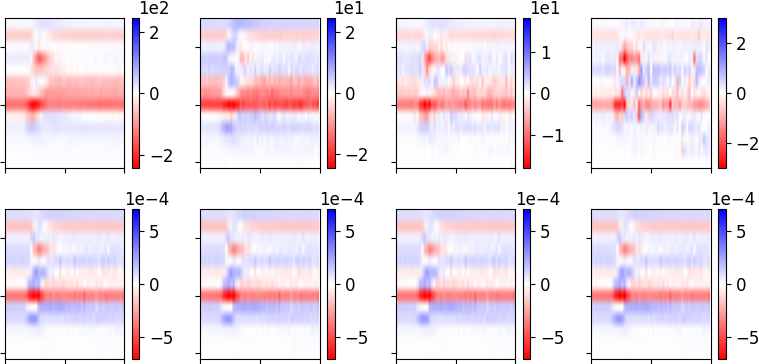

In [117]:
fig, ax = plt.subplots(2,4,figsize=(8,4))
plotFig(ax[0][0],ocsd_200.T)
plotFig(ax[0][1],ocsd_100.T)
plotFig(ax[0][2],ocsd_50.T)
plotFig(ax[0][3],ocsd_20.T)

plotFig(ax[1][0],sCsd_high_new.get_csd())
plotFig(ax[1][1],sCsd_high_new.get_csd())
plotFig(ax[1][2],sCsd_high_new.get_csd())
plotFig(ax[1][3],sCsd_high_new.get_csd())

fig, ax = plt.subplots(2,4,figsize=(8,4))
plotFig(ax[0][0],ocsd_low_200.T)
plotFig(ax[0][1],ocsd_low_100.T)
plotFig(ax[0][2],ocsd_low_50.T)
plotFig(ax[0][3],ocsd_low_20.T)

plotFig(ax[1][0],sCsd_low_new.get_csd())
plotFig(ax[1][1],sCsd_low_new.get_csd())
plotFig(ax[1][2],sCsd_low_new.get_csd())
plotFig(ax[1][3],sCsd_low_new.get_csd())

fig, ax = plt.subplots(2,4,figsize=(8,4))
plotFig(ax[0][0],ocsd_half_200.T)
plotFig(ax[0][1],ocsd_half_100.T)
plotFig(ax[0][2],ocsd_half_50.T)
plotFig(ax[0][3],ocsd_half_20.T)

plotFig(ax[1][0],sCsd_half_new.get_csd())
plotFig(ax[1][1],sCsd_half_new.get_csd())
plotFig(ax[1][2],sCsd_half_new.get_csd())
plotFig(ax[1][3],sCsd_half_new.get_csd())

fig, ax = plt.subplots(2,4,figsize=(8,4))
plotFig(ax[0][0],ocsd_quarter_200.T)
plotFig(ax[0][1],ocsd_quarter_100.T)
plotFig(ax[0][2],ocsd_quarter_50.T)
plotFig(ax[0][3],ocsd_quarter_20.T)

plotFig(ax[1][0],sCsd_quarter_new.get_csd())
plotFig(ax[1][1],sCsd_quarter_new.get_csd())
plotFig(ax[1][2],sCsd_quarter_new.get_csd())
plotFig(ax[1][3],sCsd_quarter_new.get_csd())

In [97]:
nncsd.shape

(50, 99)

In [83]:
nncsd_low.shape

(50, 49)

In [85]:
ocsd_low_200.shape

(50, 51)

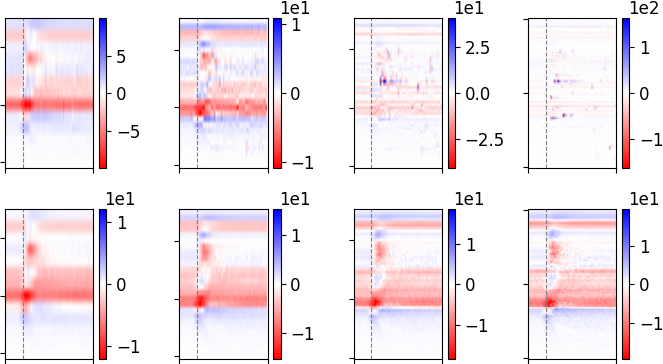

In [57]:
fig, axes = plt.subplots(2,4,figsize=(7,4))

plotFig(axes[0][0],icsd_quarter_new_200.get_csd())
plotFig(axes[0][1],icsd_half_new_200.get_csd())
plotFig(axes[0][2],icsd_low_new_200.get_csd())
plotFig(axes[0][3],icsd_high_new_200.get_csd())

plotFig(axes[1][0],ocsd_quarter_200.T*1e-12/(np.pi*(200*1e-6)**2*160*1e-6))
plotFig(axes[1][1],ocsd_half_200.T*1e-12/(np.pi*(200*1e-6)**2*80*1e-6))
plotFig(axes[1][2],ocsd_low_200.T*1e-12/(np.pi*(200*1e-6)**2*40*1e-6))
plotFig(axes[1][3],ocsd_200.T*1e-12/(np.pi*(200*1e-6)**2*20*1e-6))

for ax in axes.flat:
    ax.axvline(x=10, color='grey', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/v3Figures/csdByDensity.png',dpi=600)


In [28]:
def twoD_correlation(a, b):
    """
    Compute the normalized 2D cross-correlation between two arrays.
    Result values range from -1 (anticorrelated) to 1 (perfectly correlated).
    """
    a = a.astype(float)
    b = b.astype(float)
    # a[np.where(a>10)]=10
    # a[np.where(a<-10)]=-10

    # b[np.where(b>10)]=10
    # b[np.where(b<-10)]=-10
    
    a_mean = a.mean()
    b_mean = b.mean()
    num = np.sum((a - a_mean) * (b - b_mean))
    den = np.sqrt(np.sum((a - a_mean)**2) * np.sum((b - b_mean)**2))

    return num/den

In [26]:
def makeCorrelationMatrices(icsdList,ocsdList):

    correlationMatrices = np.zeros((len(icsdList),len(ocsdList)))
    for i in range(len(icsdList)):
        icsd = icsdList[i]
        for j in range(len(ocsdList)):
            ocsd = ocsdList[j]

            if icsd.shape!=ocsd.shape:
                ocsd=ocsd[1:-1]
                
            corr = twoD_correlation(icsd,ocsd)
            correlationMatrices[i,j] = corr

    return correlationMatrices

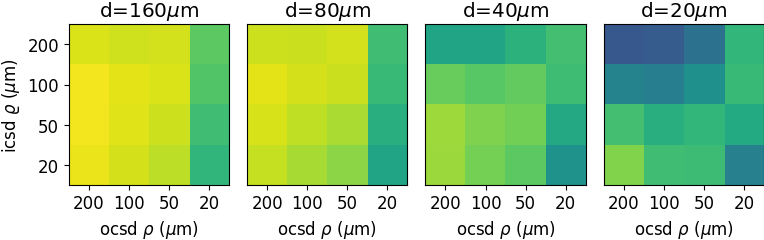

In [29]:
icsdList_high = [icsd_high_new_200.get_csd(),icsd_high_new_100.get_csd(),icsd_high_new_50.get_csd(),icsd_high_new_20.get_csd()]
icsdList_low = [icsd_low_new_200.get_csd(),icsd_low_new_100.get_csd(),icsd_low_new_50.get_csd(),icsd_low_new_20.get_csd()]
icsdList_half = [icsd_half_new_200.get_csd(),icsd_half_new_100.get_csd(),icsd_half_new_50.get_csd(),icsd_half_new_20.get_csd()]
icsdList_quarter = [icsd_quarter_new_200.get_csd(),icsd_quarter_new_100.get_csd(),icsd_quarter_new_50.get_csd(),icsd_quarter_new_20.get_csd()]

ocsdList_high = [ocsd_200.T,ocsd_100.T,ocsd_50.T,ocsd_20.T]
ocsdList_low = [ocsd_low_200.T,ocsd_low_100.T,ocsd_low_50.T,ocsd_low_20.T]
ocsdList_half = [ocsd_half_200.T,ocsd_half_100.T,ocsd_half_50.T,ocsd_half_20.T]
ocsdList_quarter = [ocsd_quarter_200.T,ocsd_quarter_100.T,ocsd_quarter_50.T,ocsd_quarter_20.T]

corrHigh = makeCorrelationMatrices(icsdList_high,ocsdList_high)
corrLow = makeCorrelationMatrices(icsdList_low,ocsdList_low)
corrHalf = makeCorrelationMatrices(icsdList_half,ocsdList_half)
corrQuarter = makeCorrelationMatrices(icsdList_quarter,ocsdList_quarter)

fig, ax = plt.subplots(1,4,figsize=(8,3))

ax[3].imshow(corrHigh,vmin=0,vmax=1)
ax[3].set_xticks([0,1,2,3],['200','100','50','20'])
ax[3].set_yticks([])
ax[3].set_xlabel(r'ocsd $\rho$ ($\mu$m)')
ax[3].set_title(r'd=20$\mu$m')

ax[2].imshow(corrLow,vmin=0,vmax=1)
ax[2].set_xticks([0,1,2,3],['200','100','50','20'])
ax[2].set_yticks([])
ax[2].set_xlabel(r'ocsd $\rho$ ($\mu$m)')
ax[2].set_title(r'd=40$\mu$m')

ax[1].imshow(corrHalf,vmin=0,vmax=1)
ax[1].set_xticks([0,1,2,3],['200','100','50','20'])
ax[1].set_yticks([])
ax[1].set_xlabel(r'ocsd $\rho$ ($\mu$m)')
ax[1].set_title(r'd=80$\mu$m')

ax[0].imshow(corrQuarter,vmin=0,vmax=1)
ax[0].set_xticks([0,1,2,3],['200','100','50','20'])
ax[0].set_yticks([0,1,2,3],['200','100','50','20'])
ax[0].set_xlabel(r'ocsd $\rho$ ($\mu$m)')
ax[0].set_ylabel(r'icsd $\varrho$ ($\mu$m)')
ax[0].set_title(r'd=160$\mu$m')

plt.tight_layout()

plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/v3Figures/fullCorrMat.png',dpi=600)


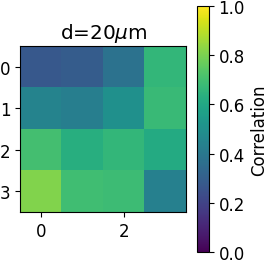

In [43]:

fig, ax = plt.subplots(1,1,figsize=(3,3))

im = ax.imshow(corrHigh,vmin=0,vmax=1)
ax.set_title(r'd=20$\mu$m')
fig.colorbar(im,ax=ax,label='Correlation')
plt.tight_layout()
plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/v3Figures/fullCorrMat_colorbar.png',dpi=600)


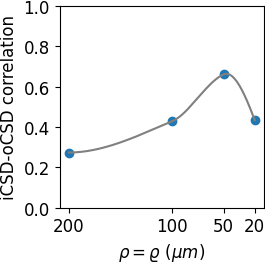

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import Akima1DInterpolator

fig, ax = plt.subplots(1,1,figsize=(3,3))

rhoValues = np.array([200, 100, 50, 20])
d20corr = np.diag(corrHigh)


rho_sorted = rhoValues[::-1]
d_sorted = d20corr[::-1]

interp = Akima1DInterpolator(rho_sorted, d_sorted)

rho_fine = np.linspace(rho_sorted.min(), rho_sorted.max(), 500)
d_fine = interp(rho_fine)

ax.plot(rho_sorted, d_sorted, 'o')
ax.plot(rho_fine, d_fine,'grey')

ax.invert_xaxis()

ax.set_xticks(rhoValues)


ax.set_xlabel(r'$\rho=\varrho$ $(\mu m)$')
ax.set_ylabel('iCSD-oCSD correlation')
ax.set_ylim([0,1])
plt.tight_layout()
plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/v3Figures/diag20.png',dpi=600)


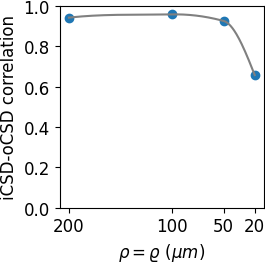

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import Akima1DInterpolator

fig, ax = plt.subplots(1,1,figsize=(3,3))

rhoValues = np.array([200, 100, 50, 20])
d160corr = np.diag(corrQuarter)

rho_sorted = rhoValues[::-1]
d_sorted = d160corr[::-1]

interp = Akima1DInterpolator(rho_sorted, d_sorted)

rho_fine = np.linspace(rho_sorted.min(), rho_sorted.max(), 500)
d_fine = interp(rho_fine)

ax.plot(rho_sorted, d_sorted, 'o')
ax.plot(rho_fine, d_fine,'grey')

ax.invert_xaxis()

ax.set_xticks(rhoValues)


ax.set_xlabel(r'$\rho=\varrho$ $(\mu m)$')
ax.set_ylabel('iCSD-oCSD correlation')
ax.set_ylim([0,1])
plt.tight_layout()
plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/v3Figures/diag160.png',dpi=600)

In [32]:
corrQuarter = (twoD_correlation(icsd_quarter_new_500.get_csd(),ocsd_quarter_500.T))
corrHalf = (twoD_correlation(icsd_half_new_500.get_csd(),ocsd_half_500.T))
corrLow = (twoD_correlation(icsd_low_new_500.get_csd(),ocsd_low_500.T))
corrHigh = (twoD_correlation(icsd_high_new_500.get_csd(),ocsd_500.T))


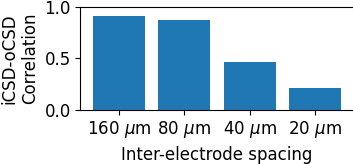

In [33]:
fig, ax = plt.subplots(1,figsize=(4,2))
plt.bar(np.arange(4), [corrQuarter, corrHalf, corrLow, corrHigh])
ax.set_xticks([0,1,2,3])
ax.set_xticklabels([r'160 $\mu$m',r'80 $\mu$m',r'40 $\mu$m',r'20 $\mu$m'])
plt.ylabel('iCSD-oCSD\nCorrelation')
plt.xlabel('Inter-electrode spacing')
plt.ylim([0,1])
plt.tight_layout()
plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/v3Figures/csdByDensity_bar.png',dpi=600)


[[0.27370262 0.28946809 0.37868129 0.6604746 ]
 [0.44610666 0.42867246 0.5017979  0.67617692]
 [0.70176422 0.62664724 0.66104382 0.61191404]
 [0.81183799 0.69477921 0.68429711 0.43435994]]


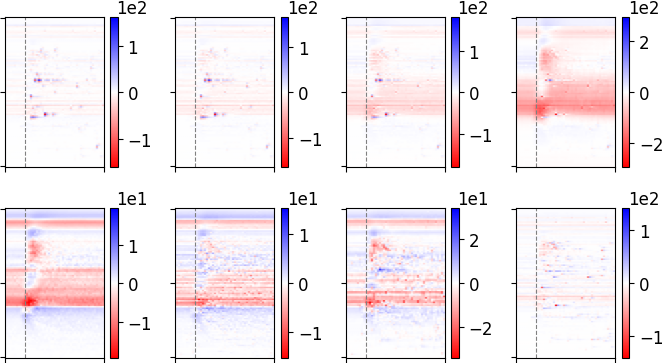

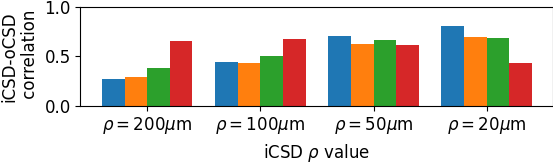

In [58]:
fig, axes = plt.subplots(2,4,figsize=(7,4))
plotFig(axes[0][0],icsd_high_new_200.get_csd())
plotFig(axes[0][1],icsd_high_new_100.get_csd())
plotFig(axes[0][2],icsd_high_new_50.get_csd())
plotFig(axes[0][3],icsd_high_new_20.get_csd())

plotFig(axes[1][0],ocsd_200.T*1e-12/(np.pi*(200e-6)**2*20e-6))
plotFig(axes[1][1],ocsd_100.T*1e-12/(np.pi*(100e-6)**2*20e-6))
plotFig(axes[1][2],ocsd_50.T*1e-12/(np.pi*(50e-6)**2*20e-6))
plotFig(axes[1][3],ocsd_20.T*1e-12/(np.pi*(20e-6)**2*20e-6))

# Add vertical dashed line at t=10 to all subplots
for ax in axes.flat:
    ax.axvline(x=10, color='grey', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/v3Figures/radii_dense.png',dpi=600)



In [40]:
sCsd_high_new.get_csd()

array([[-2.65786184e-06, -2.90595388e-06, -1.26972736e-05, ...,
        -9.28291314e-05, -4.45971513e-06, -8.72363031e-05],
       [-2.88932256e-07,  6.96291309e-06,  6.70084681e-06, ...,
        -1.52590625e-05,  5.38077465e-05,  1.05438592e-05],
       [ 4.11551326e-07,  9.92958604e-07, -2.18332801e-06, ...,
         1.67982591e-05, -3.30369149e-05,  3.77859436e-05],
       ...,
       [ 2.40479419e-04,  2.45033054e-04,  2.44951177e-04, ...,
         2.44679958e-04,  2.49985841e-04,  2.44514629e-04],
       [ 1.33386324e-04,  1.33342236e-04,  1.36556706e-04, ...,
         1.54801558e-04,  1.48953238e-04,  1.46938979e-04],
       [-9.84700023e-05, -9.91832792e-05, -9.76709117e-05, ...,
        -1.35590712e-04, -1.44031549e-04, -1.41478002e-04]],
      shape=(101, 50)) * A/m**2

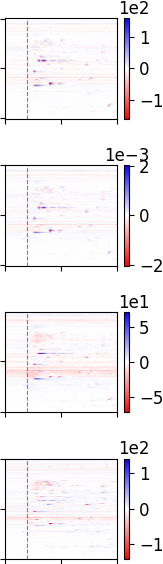

In [39]:
fig, axes = plt.subplots(4,1,figsize=(2,6))
plotFig(axes[0],icsd_high_new_200.get_csd())

plotFig(axes[1],sCsd_high_new.get_csd())

plotFig(axes[2],0.277*nncsd.T*1e-3/(20e-6)**2)

plotFig(axes[3],ocsd_20.T*1e-12/(np.pi*(20*1e-6)**2*20*1e-6))

# Add vertical dashed line at t=10 to all subplots
for ax in axes.flat:
    ax.axvline(x=10, color='grey', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/v3Figures/nnCsd.png',dpi=600)



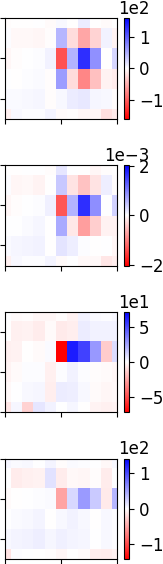

In [42]:
fig, axes = plt.subplots(4,1,figsize=(2,6))
plotFig(axes[0],icsd_high_new_200.get_csd(),xlim=(10,20),ylim=(55,60))

plotFig(axes[1],sCsd_high_new.get_csd(),xlim=(10,20),ylim=(55,60))

plotFig(axes[2],0.277*nncsd.T*1e-3/(20e-6**2),xlim=(10,20),ylim=(54,59)) # Adjusts for difference in number of electrodes

plotFig(axes[3],ocsd_20.T*1e-12/(np.pi*(20*1e-6)**2*20*1e-6),xlim=(10,20),ylim=(55,60))

plt.tight_layout()
plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/v3Figures/nnCsd_zoomed.png',dpi=600)


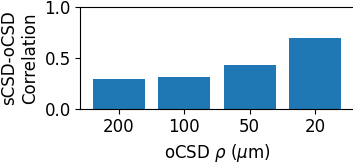

In [38]:
ocsdList = [ocsd_200.T,ocsd_100.T,ocsd_50.T,ocsd_20.T]
sCsd_correlations = []
for i in range(4):
    corr = twoD_correlation(sCsd_high_new.get_csd(),ocsdList[i])
    sCsd_correlations.append(corr)
sCsd_correlations = np.array(sCsd_correlations)

fig, ax = plt.subplots(1,figsize=(4,2))
plt.bar(np.arange(4), sCsd_correlations)
ax.set_xticks([0,1,2,3])
ax.set_xticklabels([200,100,50,20])
ax.set_xlabel(r'oCSD $\rho$ ($\mu$m)')
plt.ylabel('sCSD-oCSD\nCorrelation')
plt.ylim([0,1])
plt.tight_layout()
plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/v3Figures/SCsd_bar.png',dpi=600)


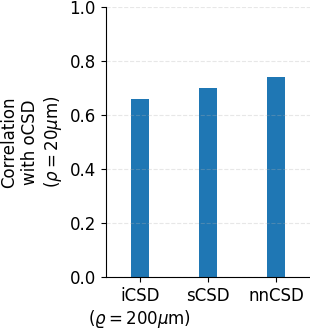

In [51]:
iCsdOcsd = twoD_correlation(icsd_high_new_200.get_csd()[1:-1], ocsd_20.T[1:-1])
sCsdOcsd = twoD_correlation(sCsd_high_new.get_csd()[1:-1], ocsd_20.T[1:-1])
nnCsdOcsd = twoD_correlation(nncsd.T, ocsd_20.T[1:-1])

fig, ax = plt.subplots(figsize=(3.2, 3.4))
ax.bar([0.2, 0.5, 0.8],
       [iCsdOcsd, sCsdOcsd, nnCsdOcsd],
       width=0.08)
ax.set_xticks([0.2, 0.5, 0.8])
ax.set_xticklabels(['iCSD\n' + r'($\varrho=200\mu$m)', 'sCSD', 'nnCSD'])
ax.set_ylabel('Correlation\nwith oCSD\n' + r'($\rho=20\mu$m)')
ax.set_ylim([0, 1])
ax.set_xlim(0.05, 0.95)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout(pad=0.3)
plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/v3Figures/nnCsd_bar.png', dpi=600)

[[0.94236817 0.92601186 0.9316881  0.748866  ]
 [0.98217156 0.95842654 0.94411215 0.7266246 ]
 [0.98190438 0.95286434 0.92559829 0.6915953 ]
 [0.96927711 0.93618593 0.90020622 0.65786435]]


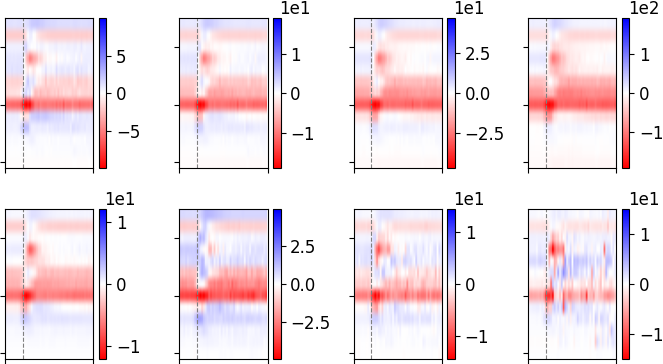

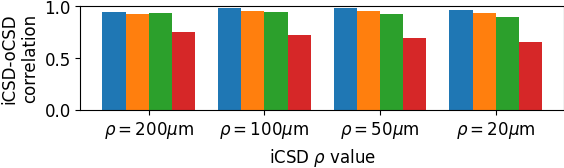

In [56]:
fig, axes = plt.subplots(2,4,figsize=(7,4))
plotFig(axes[0][0],icsd_quarter_new_200.get_csd())
plotFig(axes[0][1],icsd_quarter_new_100.get_csd())
plotFig(axes[0][2],icsd_quarter_new_50.get_csd())
plotFig(axes[0][3],icsd_quarter_new_20.get_csd())

plotFig(axes[1][0],ocsd_quarter_200.T*1e-12/(np.pi*(200e-6)**2*160e-6))
plotFig(axes[1][1],ocsd_quarter_100.T*1e-12/(np.pi*(100e-6)**2*160e-6))
plotFig(axes[1][2],ocsd_quarter_50.T*1e-12/(np.pi*(50e-6)**2*160e-6))
plotFig(axes[1][3],ocsd_quarter_20.T*1e-12/(np.pi*(20e-6)**2*160e-6))

# Add vertical dashed line at t=10 to all subplots
for ax in axes.flat:
    ax.axvline(x=10, color='grey', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/v3Figures/radii_coarse.png',dpi=600)


